# Outlier pratice


In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Dell\outlier\outlier_detection_practice_dataset.csv")
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               200 non-null    int64
 1   experience_years  200 non-null    int64
 2   salary            200 non-null    int64
 3   loan_amount       200 non-null    int64
 4   credit_score      200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


,age,experience_years,salary,loan_amount,credit_score
count,200.0000,200.000000,200.000000,2.000000e+02,200.000000
mean,40.9900,16.660000,62845.670000,3.671217e+05,681.875000
std,13.2145,11.409878,59503.388518,3.890062e+05,106.337565
min,21.0000,0.000000,25412.000000,5.040400e+04,110.000000
25%,29.0000,6.000000,42066.750000,2.000815e+05,608.000000
50%,42.0000,17.000000,54910.000000,3.338485e+05,674.500000
75%,52.0000,26.000000,71503.750000,4.743400e+05,772.500000
max,100.0000,40.000000,600000.000000,4.000000e+06,849.000000


In [3]:
# Missing values
df.isnull().sum()


age                 0
experience_years    0
salary              0
loan_amount         0
credit_score        0
dtype: int64

In [4]:
# Numerical columns identify
numerical_columns = df.select_dtypes(include=['number']).columns
print("Numerical columns:", numerical_columns)

Numerical columns: Index(['age', 'experience_years', 'salary', 'loan_amount', 'credit_score'], dtype='str')


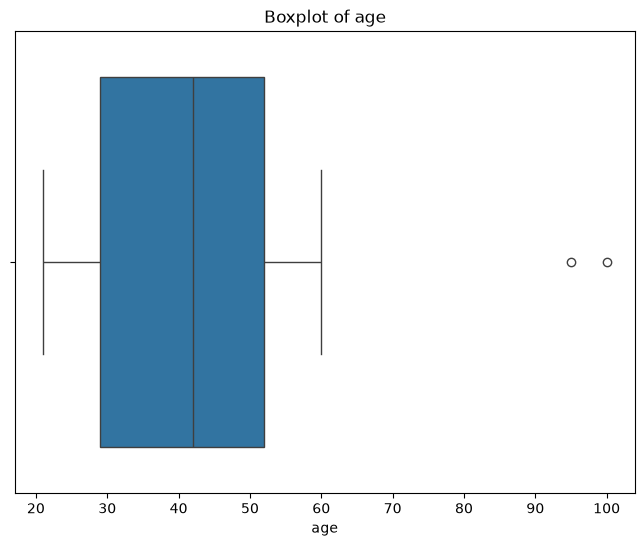

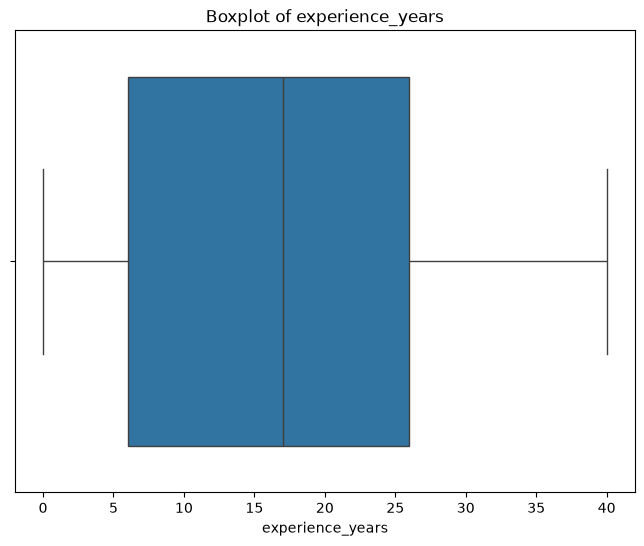

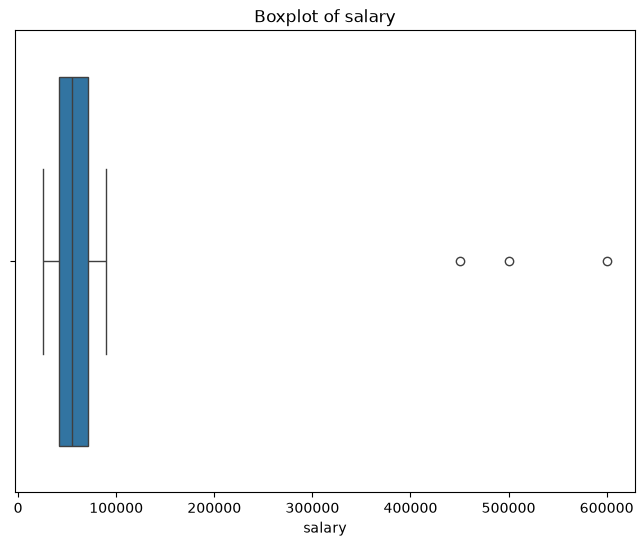

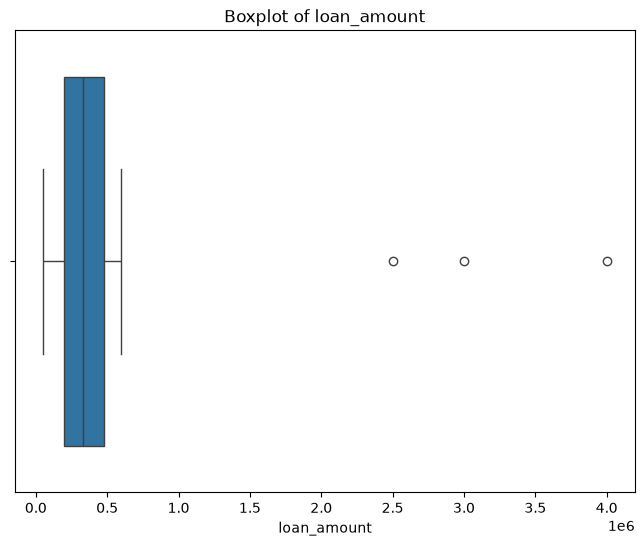

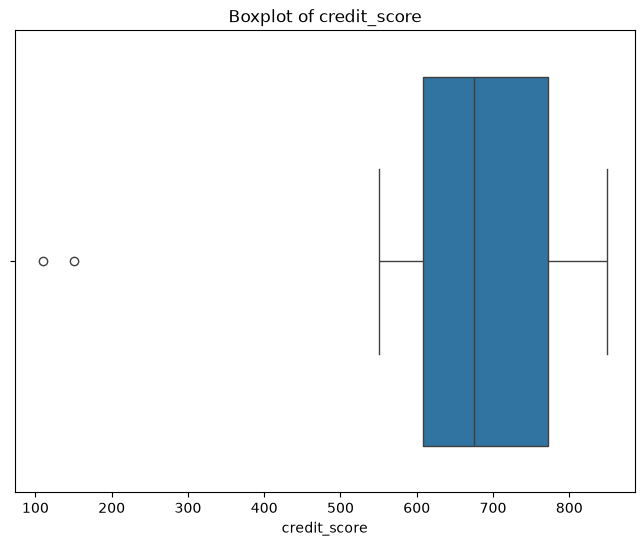

In [5]:
# show outliers using boxplot
import matplotlib.pyplot as plt
import seaborn as sns
for column in numerical_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()


In [6]:
# applying IQR method to detect outliers
q1 = df[numerical_columns].quantile(0.25)
q3 = df[numerical_columns].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print("Lower Bound:\n", lower_bound)
print("Upper Bound:\n", upper_bound)

Lower Bound:
 age                     -5.50
experience_years       -24.00
salary               -2088.75
loan_amount        -211306.25
credit_score           361.25
dtype: float64
Upper Bound:
 age                     86.50
experience_years        56.00
salary              115659.25
loan_amount         885727.75
credit_score          1019.25
dtype: float64


In [8]:
# import outlier detection libraries
outlier = df[(df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound)]

In [9]:
print(outlier)

     age  experience_years  salary  loan_amount  credit_score
0    NaN               NaN     NaN          NaN           NaN
1    NaN               NaN     NaN          NaN           NaN
2    NaN               NaN     NaN          NaN           NaN
3    NaN               NaN     NaN          NaN           NaN
4    NaN               NaN     NaN          NaN           NaN
..   ...               ...     ...          ...           ...
195  NaN               NaN     NaN          NaN           NaN
196  NaN               NaN     NaN          NaN           NaN
197  NaN               NaN     NaN          NaN           NaN
198  NaN               NaN     NaN          NaN           NaN
199  NaN               NaN     NaN          NaN           NaN

[200 rows x 5 columns]


In [10]:
# how many outliers are there in each numerical column
print("number of outliers:",len(outlier))

number of outliers: 200


In [11]:
# axis=1 means we are checking for outliers in each row, if any column has an outlier, that row will be considered as an outlier
outlier = df[(df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound)].any(axis=1)
print("Number of rows with outliers:", outlier.sum())

Number of rows with outliers: 10


In [13]:
# show q1, q3, iqr, lower_bound, upper_bound for each numerical column
print("Q1:\n", q1)
print("Q3:\n", q3)
print("IQR:\n", iqr)
print("Lower Bound:\n", lower_bound)
print("Upper Bound:\n", upper_bound)
print("Outliers:\n", outlier)


Q1:
 age                     29.00
experience_years         6.00
salary               42066.75
loan_amount         200081.50
credit_score           608.00
Name: 0.25, dtype: float64
Q3:
 age                     52.00
experience_years        26.00
salary               71503.75
loan_amount         474340.00
credit_score           772.50
Name: 0.75, dtype: float64
IQR:
 age                     23.0
experience_years        20.0
salary               29437.0
loan_amount         274258.5
credit_score           164.5
dtype: float64
Lower Bound:
 age                     -5.50
experience_years       -24.00
salary               -2088.75
loan_amount        -211306.25
credit_score           361.25
dtype: float64
Upper Bound:
 age                     86.50
experience_years        56.00
salary              115659.25
loan_amount         885727.75
credit_score          1019.25
dtype: float64
Outliers:
 0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    Fal

In [18]:
# z-score method to detect outliers
mean = df['salary'].mean()
print("Mean:", mean)
std = df['salary'].std()
print("Standard Deviation:", std)


Mean: 62845.67
Standard Deviation: 59503.388517600244


In [23]:
z = (df["salary"] - mean) / std
print(z)

0     -0.142356
1     -0.473648
2     -0.350932
3      0.168853
4      0.307719
         ...   
195   -0.448238
196   -0.250753
197    0.383043
198   -0.005860
199   -0.478925
Name: salary, Length: 200, dtype: float64


In [24]:
outliers = df[abs(z) > 3]

print("Number of outliers:", len(outliers))

Number of outliers: 3


In [25]:
print(outliers[["salary"]])

    salary
5   450000
25  500000
75  600000


In [26]:
median = df["salary"].median()

print("Median:", median)

Median: 54910.0


In [27]:
# MAD Median Absolute Deviation
absolute_deviation = abs(df["salary"] - median)

mad = absolute_deviation.median()

print("MAD:", mad)

MAD: 14840.5


In [28]:
# modifie Z-score
modified_z = 0.6745 * (df["salary"] - median) / mad

print(modified_z)

0     -0.024316
1     -0.920271
2     -0.588395
3      0.817326
4      1.192879
         ...   
195   -0.851550
196   -0.317468
197    1.396586
198    0.344829
199   -0.934542
Name: salary, Length: 200, dtype: float64


In [29]:
abs(modified_z) > 3.5

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Name: salary, Length: 200, dtype: bool

In [30]:
outliers = df[abs(modified_z) > 3.5]

print("Number of outliers:", len(outliers))
print(outliers[["salary"]])

Number of outliers: 3
    salary
5   450000
25  500000
75  600000


In [4]:
# isolation Forest
numerical_columns = [
    "age",
    "experience_years",
    "salary",
    "loan_amount",
    "credit_score"
]

X = df[numerical_columns]

In [5]:
df.head()

,age,experience_years,salary,loan_amount,credit_score
0,59,34,54375,88102,595
1,49,27,34662,124460,583
2,35,12,41964,414778,627
3,28,5,72893,139930,767
4,41,19,81156,581089,622


In [6]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(X)

prediction = model.predict(X)

In [7]:
outliers = df[prediction == -1]

print("Number of outliers:", len(outliers))
print(outliers)

Number of outliers: 10
     age  experience_years  salary  loan_amount  credit_score
5     59                30  450000       229208           831
15    42                21   86389      2500000           575
25    45                16  500000       207504           763
35    95                31   84101        76790           660
45    27                 4   65158       223416           150
55    24                 0   52663      3000000           761
75    49                24  600000        61023           775
90   100                31   37161       547562           589
120   35                 6   52384      4000000           842
145   50                29   72320       531680           110


In [7]:
# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
numerical_columns = [
    "age",
    "experience_years",
    "salary",
    "loan_amount",
    "credit_score"
]

X = df[numerical_columns]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
from sklearn.cluster import DBSCAN

model = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = model.fit_predict(X_scaled)
outliers = df[labels == -1]

print("Number of outliers:", len(outliers))
print(outliers)


Number of outliers: 169
     age  experience_years  salary  loan_amount  credit_score
0     59                34   54375        88102           595
1     49                27   34662       124460           583
4     41                19   81156       581089           622
5     59                30  450000       229208           831
6     39                17   33130       204697           798
..   ...               ...     ...          ...           ...
195   42                14   36174       391396           559
196   31                 4   47925       180560           554
197   36                12   85638       416824           672
198   53                33   62497       197979           667
199   29                 3   34348       199849           843

[169 rows x 5 columns]


In [8]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

distances = distances[:, 4]

distances = sorted(distances)

In [9]:
print(distances)

[np.float64(0.4597095820983139), np.float64(0.4692380702995883), np.float64(0.48546831409218216), np.float64(0.4863057519109338), np.float64(0.49426326277909777), np.float64(0.4955092803507297), np.float64(0.49635695219646814), np.float64(0.49797461017763645), np.float64(0.4986647415332913), np.float64(0.5040154595131627), np.float64(0.505722938085761), np.float64(0.508431473981544), np.float64(0.5164552649301084), np.float64(0.5168341842478905), np.float64(0.5316803075454335), np.float64(0.5344667583445034), np.float64(0.5374449265539494), np.float64(0.5374449265539494), np.float64(0.5397276988305033), np.float64(0.5477413581775296), np.float64(0.5506605822435038), np.float64(0.5540546143675424), np.float64(0.5605541448265043), np.float64(0.5649773532237116), np.float64(0.5668810807542597), np.float64(0.5669856691580271), np.float64(0.5689139735570441), np.float64(0.5712084004714767), np.float64(0.5745567735583881), np.float64(0.5746338725983042), np.float64(0.5756679274089341), np.fl

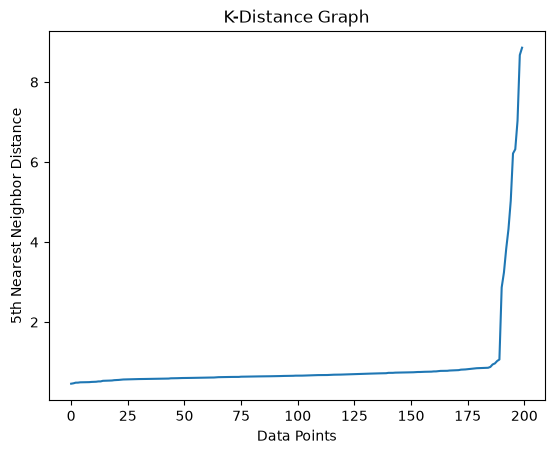

In [10]:
import matplotlib.pyplot as plt

plt.plot(distances)
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph")
plt.show()